# Institutional BTCC – Regime Detection v10: Backtest
Replicates the Pine Script strategy logic on **BTC-USD 1H** data (last 12 months).

### Strategy Rules
| Parameter | Value |
|---|---|
| EMA trend filter | 200-period EMA |
| MACD | 12 / 26 / 9 |
| Bollinger Bands | 20-period, 2 std dev |
| Volume filter | Close > 20-period vol SMA |
| ADX trend filter | 14-period, trending if ADX > 25 |
| Panic volatility | ATR14 > ATR60-SMA × 1.4 → no trades |
| Long entry | close > EMA200 AND MACD > Signal AND close > BB Upper AND volume > VolSMA AND trending AND NOT panic |
| Short entry | close < EMA200 AND MACD < Signal AND close < BB Lower AND volume > VolSMA AND trending AND NOT panic |
| Stop loss | entry ± ATR × 3.0 |
| Trailing stop | activates after price moves ATR×3 in favor, then trails ATR×3 from the best price |
| Position size | 1 % of equity at risk per trade (risk-based sizing) |
| Initial capital | $10,000 |
| Commission | 0.06 % per trade |

In [1]:
# ── 0. Install / import ──────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["yfinance", "pandas", "numpy", "matplotlib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

print("Libraries ready")

Libraries ready


In [14]:
# ── 1. Download data ─────────────────────────────────────────────────────────
df = yf.download("BTC-USD", period="60d", interval="15m", auto_adjust=True, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)
print(f"Rows: {len(df)}  |  {df.index[0]}  →  {df.index[-1]}")
df.tail(3)

Rows: 5751  |  2026-01-02 00:00:00+00:00  →  2026-03-02 21:30:00+00:00


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-03-02 21:00:00+00:00,69171.976562,69233.812500,69052.085938,69189.367188,207208448
2026-03-02 21:15:00+00:00,69304.671875,69402.054688,69218.351562,69358.656250,393568256
2026-03-02 21:30:00+00:00,69433.539062,69442.968750,69388.437500,69423.453125,73400320


In [15]:
# ── 2. Indicators ─────────────────────────────────────────────────────────────

# EMA 200
df["EMA200"] = df["Close"].ewm(span=200, adjust=False).mean()

# MACD (12, 26, 9)
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]       = ema12 - ema26
df["MACDSignal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Bollinger Bands (20, 2)
bb_mid          = df["Close"].rolling(20).mean()
bb_std          = df["Close"].rolling(20).std()
df["BBMid"]     = bb_mid
df["BBUpper"]   = bb_mid + 2 * bb_std
df["BBLower"]   = bb_mid - 2 * bb_std

# Volume SMA 20
df["VolSMA"] = df["Volume"].rolling(20).mean()

# ATR 14 (Wilder smoothing = EWM alpha=1/14)
high_low  = df["High"] - df["Low"]
high_pc   = (df["High"] - df["Close"].shift(1)).abs()
low_pc    = (df["Low"]  - df["Close"].shift(1)).abs()
tr        = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df["ATR14"] = tr.ewm(alpha=1/14, adjust=False).mean()

# ATR 60-bar SMA (baseline volatility)
df["ATR60SMA"] = df["ATR14"].rolling(60).mean()

# ADX / DMI (14)
up_move   = df["High"] - df["High"].shift(1)
dn_move   = df["Low"].shift(1) - df["Low"]
plus_dm   = np.where((up_move > dn_move) & (up_move > 0), up_move, 0.0)
minus_dm  = np.where((dn_move > up_move) & (dn_move > 0), dn_move, 0.0)
smoothed_plus_dm  = pd.Series(plus_dm,  index=df.index).ewm(alpha=1/14, adjust=False).mean()
smoothed_minus_dm = pd.Series(minus_dm, index=df.index).ewm(alpha=1/14, adjust=False).mean()
df["DI_plus"]  = 100 * smoothed_plus_dm  / df["ATR14"]
df["DI_minus"] = 100 * smoothed_minus_dm / df["ATR14"]
dx             = 100 * (df["DI_plus"] - df["DI_minus"]).abs() / (df["DI_plus"] + df["DI_minus"])
df["ADX"]      = dx.ewm(alpha=1/14, adjust=False).mean()

df.dropna(inplace=True)

# Regime flags
df["isTrending"]       = df["ADX"] > 25
df["isPanicVolatility"] = df["ATR14"] > (df["ATR60SMA"] * 1.4)

print("Indicators calculated. Sample:")
df[["Close","EMA200","MACD","MACDSignal","BBUpper","BBLower","ADX","isTrending","isPanicVolatility"]].tail(5)

Indicators calculated. Sample:


Price,Close,EMA200,MACD,MACDSignal,BBUpper,BBLower,ADX,isTrending,isPanicVolatility
Datetime,,,,,,,,,
2026-03-02 20:30:00+00:00,69200.531250,66831.962278,396.919498,508.206948,69701.217634,68566.487834,32.788039,True,False
2026-03-02 20:45:00+00:00,69291.546875,66856.435757,395.213548,485.608268,69715.845641,68574.775453,33.299861,True,False
2026-03-02 21:00:00+00:00,69189.367188,66879.649005,381.222034,464.731021,69648.250229,68598.752115,32.998631,True,False
2026-03-02 21:15:00+00:00,69358.656250,66904.315744,379.420151,447.668847,69644.653180,68599.945258,33.084748,True,False
2026-03-02 21:30:00+00:00,69423.453125,66929.381787,378.853524,433.905782,69591.752194,68629.600931,33.251953,True,False


In [16]:
# ── 3. Entry signals ──────────────────────────────────────────────────────────
df["LongSignal"] = (
    (df["Close"] > df["EMA200"]) &
    (df["MACD"]  > df["MACDSignal"]) &
    (df["Close"] > df["BBUpper"]) &
    (df["Volume"] > df["VolSMA"]) &
    df["isTrending"] &
    ~df["isPanicVolatility"]
)

df["ShortSignal"] = (
    (df["Close"] < df["EMA200"]) &
    (df["MACD"]  < df["MACDSignal"]) &
    (df["Close"] < df["BBLower"]) &
    (df["Volume"] > df["VolSMA"]) &
    df["isTrending"] &
    ~df["isPanicVolatility"]
)

print(f"Long signals : {df['LongSignal'].sum()}")
print(f"Short signals: {df['ShortSignal'].sum()}")

Long signals : 28
Short signals: 57


In [17]:
# ── 4. Backtest simulation (bar-by-bar loop) ──────────────────────────────────
# Trailing stop logic mirrors Pine Script:
#   trail_points = trail_offset = ATR * 3 (in price units)
#   → trailing stop activates once price moves ATR*3 in favor
#   → then trails ATR*3 behind the best price

INITIAL_CAPITAL = 10_000.0
RISK_PCT        = 0.01    # 1% of equity per trade
ATR_MULT        = 3.0     # stop distance = ATR * 3
COMMISSION_PCT  = 0.0006  # 0.06% per side

equity       = INITIAL_CAPITAL
position     = None
trades       = []
equity_curve = []

for ts, row in df.iterrows():
    close  = float(row["Close"])
    high   = float(row["High"])
    low    = float(row["Low"])
    atr    = float(row["ATR14"])
    stop_dist = atr * ATR_MULT

    # ── Manage open position ──────────────────────────────────────────────
    if position is not None:
        direction = position["direction"]

        if direction == "long":
            # Update best price
            if high > position["best_price"]:
                position["best_price"] = high
            # Trailing stop activates once best_price >= entry + trail_points
            trail_threshold = position["entry"] + position["trail_points"]
            if position["best_price"] >= trail_threshold:
                trail_sl = position["best_price"] - position["trail_offset"]
                position["sl"] = max(position["sl"], trail_sl)
            exit_triggered = low <= position["sl"]
            exit_price     = position["sl"] if exit_triggered else None

        else:  # short
            if low < position["best_price"]:
                position["best_price"] = low
            trail_threshold = position["entry"] - position["trail_points"]
            if position["best_price"] <= trail_threshold:
                trail_sl = position["best_price"] + position["trail_offset"]
                position["sl"] = min(position["sl"], trail_sl)
            exit_triggered = high >= position["sl"]
            exit_price     = position["sl"] if exit_triggered else None

        if exit_triggered:
            if direction == "long":
                pnl_pct = (exit_price - position["entry"]) / position["entry"]
            else:
                pnl_pct = (position["entry"] - exit_price) / position["entry"]

            dollar_pnl  = pnl_pct * position["notional"]
            commission  = position["notional"] * COMMISSION_PCT * 2  # entry + exit
            dollar_pnl -= commission
            equity     += dollar_pnl
            trades.append({
                "entry_time" : position["entry_time"],
                "exit_time"  : ts,
                "direction"  : direction,
                "entry"      : position["entry"],
                "exit"       : exit_price,
                "sl_initial" : position["sl_initial"],
                "pnl_pct"    : round(pnl_pct * 100, 3),
                "dollar_pnl" : round(dollar_pnl, 2),
                "equity"     : round(equity, 2),
            })
            position = None

    # ── Check for new entry ───────────────────────────────────────────────
    if position is None:
        if bool(row["LongSignal"]):
            risk_capital = equity * RISK_PCT
            qty          = risk_capital / stop_dist        # shares / units
            notional     = qty * close
            position = {
                "direction"   : "long",
                "entry"       : close,
                "entry_time"  : ts,
                "sl"          : close - stop_dist,
                "sl_initial"  : close - stop_dist,
                "best_price"  : close,
                "trail_points": stop_dist,
                "trail_offset": stop_dist,
                "notional"    : notional,
            }
        elif bool(row["ShortSignal"]):
            risk_capital = equity * RISK_PCT
            qty          = risk_capital / stop_dist
            notional     = qty * close
            position = {
                "direction"   : "short",
                "entry"       : close,
                "entry_time"  : ts,
                "sl"          : close + stop_dist,
                "sl_initial"  : close + stop_dist,
                "best_price"  : close,
                "trail_points": stop_dist,
                "trail_offset": stop_dist,
                "notional"    : notional,
            }

    equity_curve.append({"time": ts, "equity": equity})

print(f"Simulation complete.  Trades found: {len(trades)}")

Simulation complete.  Trades found: 50


In [18]:
# ── 5. Summary statistics ─────────────────────────────────────────────────────
tdf = pd.DataFrame(trades)

if tdf.empty:
    print("No trades executed in this period.")
else:
    wins      = tdf[tdf["dollar_pnl"] > 0]
    losses    = tdf[tdf["dollar_pnl"] <= 0]
    win_rate  = len(wins) / len(tdf) * 100
    avg_win   = wins["dollar_pnl"].mean()   if not wins.empty   else 0
    avg_loss  = losses["dollar_pnl"].mean() if not losses.empty else 0
    total_pnl = tdf["dollar_pnl"].sum()
    final_eq  = tdf["equity"].iloc[-1]

    longs_count  = (tdf["direction"] == "long").sum()
    shorts_count = (tdf["direction"] == "short").sum()

    # Max drawdown on equity curve
    eq_series = pd.Series([t["equity"] for t in equity_curve])
    roll_max  = eq_series.cummax()
    drawdown  = (eq_series - roll_max) / roll_max * 100
    max_dd    = drawdown.min()

    # Profit factor
    gross_profit = wins["dollar_pnl"].sum()   if not wins.empty   else 0
    gross_loss   = losses["dollar_pnl"].sum() if not losses.empty else 0
    profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else float("inf")

    print("=" * 50)
    print(f"  BACKTEST RESULTS  (BTC-USD 15m, 60 days)")
    print("=" * 50)
    print(f"  Initial capital   : ${INITIAL_CAPITAL:>10,.2f}")
    print(f"  Final equity      : ${final_eq:>10,.2f}")
    print(f"  Net P&L           : ${total_pnl:>+10,.2f}")
    print(f"  Return            : {(final_eq/INITIAL_CAPITAL - 1)*100:>+9.2f} %")
    print(f"  Max drawdown      : {max_dd:>9.2f} %")
    print(f"  Profit factor     : {profit_factor:>9.2f}")
    print("-" * 50)
    print(f"  Total trades      : {len(tdf):>5}")
    print(f"    Long trades     : {longs_count:>5}")
    print(f"    Short trades    : {shorts_count:>5}")
    print(f"  Winners           : {len(wins):>5}")
    print(f"  Losers            : {len(losses):>5}")
    print(f"  Win rate          : {win_rate:>8.1f} %")
    print(f"  Avg win  $        : ${avg_win:>+9,.2f}")
    print(f"  Avg loss $        : ${avg_loss:>+9,.2f}")
    print(f"  Best trade $      : ${tdf['dollar_pnl'].max():>+9,.2f}")
    print(f"  Worst trade $     : ${tdf['dollar_pnl'].min():>+9,.2f}")
    print("=" * 50)

tdf

  BACKTEST RESULTS  (BTC-USD 15m, 60 days)
  Initial capital   : $ 10,000.00
  Final equity      : $  8,938.06
  Net P&L           : $ -1,061.93
  Return            :    -10.62 %
  Max drawdown      :    -11.73 %
  Profit factor     :      0.59
--------------------------------------------------
  Total trades      :    50
    Long trades     :    19
    Short trades    :    31
  Winners           :    24
  Losers            :    26
  Win rate          :     48.0 %
  Avg win  $        : $   +62.88
  Avg loss $        : $   -98.89
  Best trade $      : $  +239.66
  Worst trade $     : $  -151.69


,entry_time,exit_time,direction,entry,exit,sl_initial,pnl_pct,dollar_pnl,equity
0,2026-01-03 22:15:00+00:00,2026-01-04 00:00:00+00:00,long,90631.054688,91093.049149,90333.377274,0.510,118.66,10118.66
1,2026-01-04 06:00:00+00:00,2026-01-04 06:45:00+00:00,long,91649.789062,91244.125605,91244.125605,-0.443,-128.62,9990.04
2,2026-01-07 19:00:00+00:00,2026-01-08 07:45:00+00:00,short,90683.140625,90369.322712,91474.150837,0.346,25.89,10015.94
3,2026-01-08 14:30:00+00:00,2026-01-08 14:45:00+00:00,short,89364.492188,89967.485320,89967.485320,-0.675,-117.97,9897.96
4,2026-01-09 08:30:00+00:00,2026-01-09 08:45:00+00:00,short,90228.914062,90100.746435,90701.090185,0.142,4.17,9902.13
5,2026-01-09 08:45:00+00:00,2026-01-09 10:15:00+00:00,short,89845.132812,90412.227159,90412.227159,-0.631,-117.85,9784.29
6,2026-01-11 14:45:00+00:00,2026-01-11 15:00:00+00:00,long,91043.945312,90845.442661,90845.442661,-0.218,-151.69,9632.59
7,2026-01-12 15:15:00+00:00,2026-01-12 17:30:00+00:00,long,91183.132812,91476.448120,90449.432495,0.322,24.14,9656.74
8,2026-01-13 09:15:00+00:00,2026-01-13 09:30:00+00:00,long,92448.898438,91939.072238,91939.072238,-0.551,-117.58,9539.16
9,2026-01-13 20:00:00+00:00,2026-01-13 22:00:00+00:00,long,94359.984375,95082.226311,93589.257561,0.765,75.38,9614.53


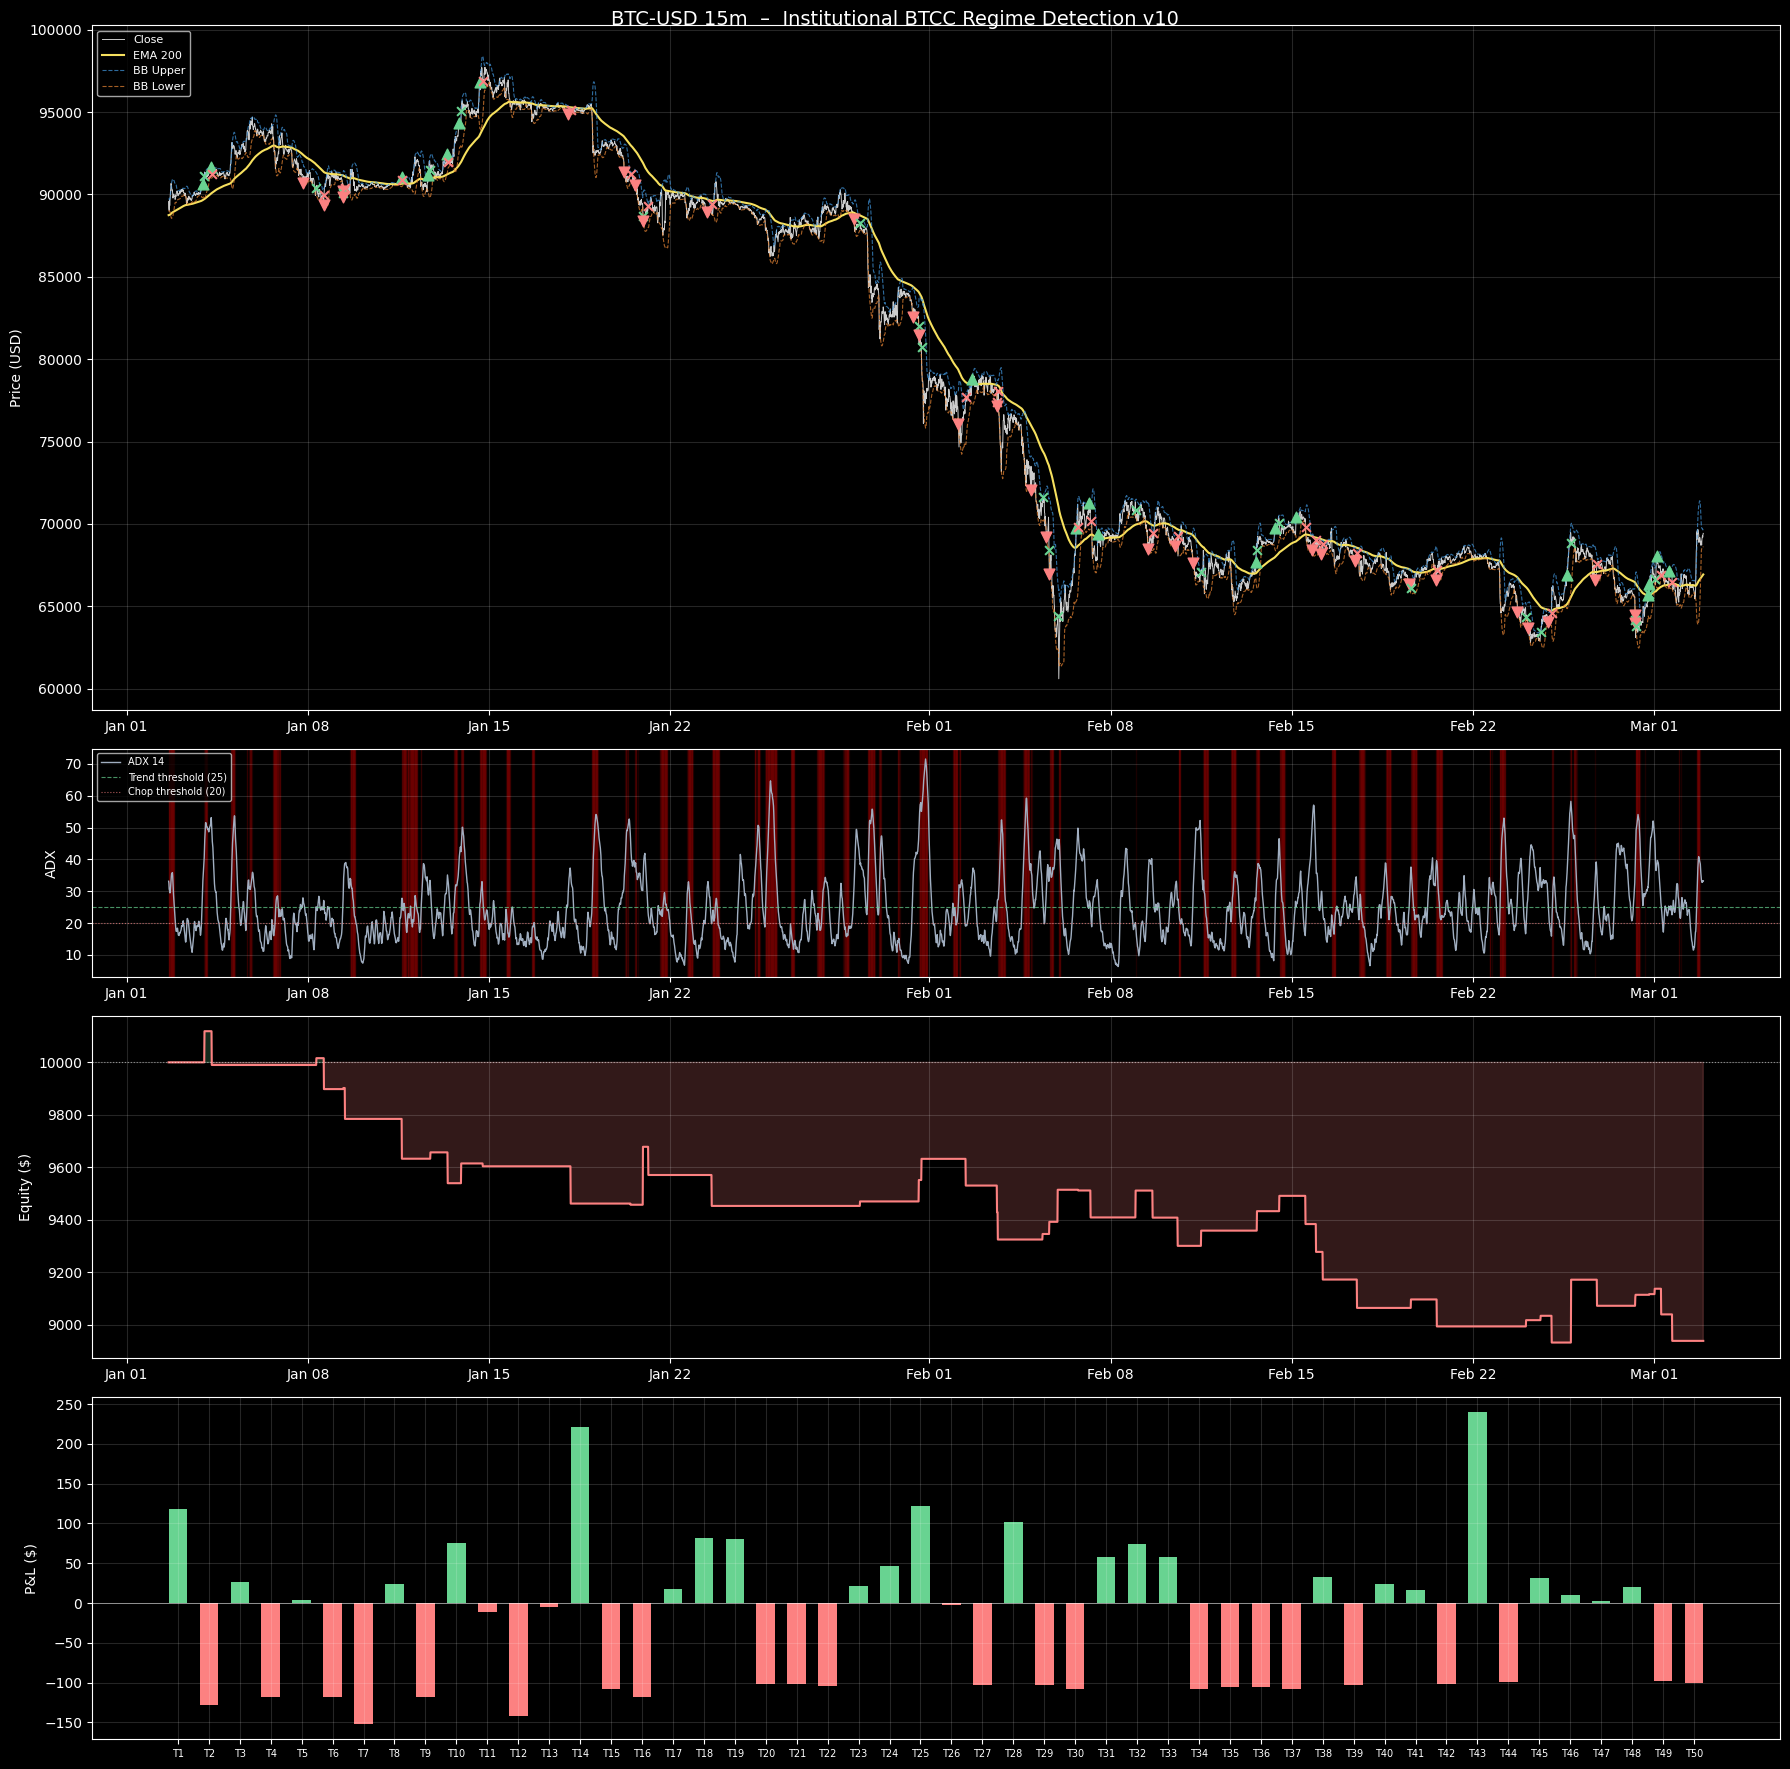

Chart saved → backtest_btcc_regime_results.png


In [19]:
# ── 6. Charts ─────────────────────────────────────────────────────────────────
ec_df = pd.DataFrame(equity_curve).set_index("time")

fig, axes = plt.subplots(4, 1, figsize=(18, 18),
                          gridspec_kw={"height_ratios": [3, 1, 1.5, 1.5]})
fig.suptitle("BTC-USD 15m  –  Institutional BTCC Regime Detection v10", fontsize=14)
plt.style.use("dark_background")

# ── Panel 1: Price + EMA200 + BB + entry/exit signals ────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],   color="#cccccc", lw=0.7, label="Close")
ax1.plot(df.index, df["EMA200"],  color="#f6e05e", lw=1.5, label="EMA 200")
ax1.plot(df.index, df["BBUpper"], color="#4299e1", lw=0.8, ls="--", alpha=0.7, label="BB Upper")
ax1.plot(df.index, df["BBLower"], color="#ed8936", lw=0.8, ls="--", alpha=0.7, label="BB Lower")

if not tdf.empty:
    for _, t in tdf.iterrows():
        win_color = "#68d391" if t["dollar_pnl"] >= 0 else "#fc8181"
        mrkr = "^" if t["direction"] == "long" else "v"
        ax1.scatter(t["entry_time"], t["entry"], marker=mrkr,
                    color=("#68d391" if t["direction"] == "long" else "#fc8181"), s=60, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="x", color=win_color, s=40, zorder=5)

ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2: ADX + regime shading ────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(df.index, df["ADX"], color="#a0aec0", lw=1.0, label="ADX 14")
ax2.axhline(25, color="#68d391", ls="--", lw=0.8, alpha=0.7, label="Trend threshold (25)")
ax2.axhline(20, color="#fc8181", ls=":",  lw=0.8, alpha=0.7, label="Chop threshold (20)")
# Shade panic volatility bars
panic_bars = df[df["isPanicVolatility"]]
for ts_p in panic_bars.index:
    ax2.axvspan(ts_p, ts_p, alpha=0.1, color="red")
ax2.set_ylabel("ADX")
ax2.legend(loc="upper left", fontsize=7)
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3: Equity curve ─────────────────────────────────────────────────────
ax3 = axes[2]
final_val    = ec_df["equity"].iloc[-1]
color_line   = "#68d391" if final_val >= INITIAL_CAPITAL else "#fc8181"
ax3.plot(ec_df.index, ec_df["equity"], color=color_line, lw=1.5)
ax3.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax3.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] >= INITIAL_CAPITAL, alpha=0.2, color="#68d391")
ax3.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] < INITIAL_CAPITAL,  alpha=0.2, color="#fc8181")
ax3.set_ylabel("Equity ($)")
ax3.grid(alpha=0.15)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 4: Per-trade P&L bars ───────────────────────────────────────────────
ax4 = axes[3]
if not tdf.empty:
    bar_colors = ["#68d391" if v >= 0 else "#fc8181" for v in tdf["dollar_pnl"]]
    ax4.bar(range(len(tdf)), tdf["dollar_pnl"], color=bar_colors, width=0.6)
    ax4.axhline(0, color="white", lw=0.7, alpha=0.5)
    ax4.set_xticks(range(len(tdf)))
    ax4.set_xticklabels([f"T{i+1}" for i in range(len(tdf))], fontsize=7)
ax4.set_ylabel("P&L ($)")
ax4.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("backtest_btcc_regime_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → backtest_btcc_regime_results.png")